# Transient vs quasi-steady PEMFC simulation — comparison with MEA62 data

This notebook replays the MEA62 test-bench polarisation curve (the same log used in
notebook 03) through two simulation approaches:

* **Quasi-steady state (QSS):** `ExplicitSteadyStateModel` is called independently at
  each logged sample, ignoring thermal and water-transport inertia.
* **Transient:** `TransientModel` integrates the coupled MEA-temperature / membrane
  water-content ODEs (Ferrara et al., 2018) under continuously time-varying logged
  conditions.

After comparing both against the measured voltage, the notebook shows how the
membrane water-content profile evolves throughout the polarisation curve.

**Note:** both models use the same MEA62 parameter set estimated in
`02_parameter_estimation.ipynb`.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import marapendi as mrpd
from marapendi.cell.transient import TransientModel
from marapendi.cell.explicit_steady_state import ExplicitSteadyStateModel

## 1 — Load the MEA62 log

Same pre-processing as notebook 03.

In [2]:
df = pd.read_csv('monocell_datas_03Mar2026_08h10.csv', sep=';', skiprows=6, encoding='latin1')
df = df.rename(columns=lambda c: c.strip())

old_columns = list(df.columns)
df = df.reset_index()
df.columns = ['Time(s)'] + old_columns[1:] + ['_extra']
df = df.drop(columns=['_extra'])
df['Time(h)'] = (df['Time(s)'] - df['Time(s)'].iloc[0]) / 3600.

CELL_AREA  = 25e-4   # m²
N_CELLS    = 1
I_MIN      = 0.5     # A
T_START_H  = 1.6     # h — start of polarisation curve window
T_END_H    = 2.8     # h

print(f"Log length: {len(df)} samples over {df['Time(h)'].iloc[-1]:.2f} h")

Log length: 26565 samples over 7.38 h


## 2 — MEA62 cell assembly

Same 18-parameter estimated configuration as notebook 03.

In [3]:
fixed_parameters = {
    'radius-carbon': 25e-9, 'ionomer-E-act-cond': 15e6, 'n_s': 2,
    'ionomer-k1': 8.5, 'ionomer-k2': 5.4, 'ionomer-k3': 5.4,
    'gdl-porosity': 0.6, 'pt-wt-percent': 0.4, 'ch-height': 1e-3,
    'gdl-thickness': 150e-6, 'gdl-theta': 120.,
    'gdl-eff-diff-ratio': 0.3, 'cl-abs-perm': 1e-13,
    'wet-transition': 0.4, 'pt-loading': .3e-2, 'ic-ratio': 1.4,
    'ecsa': 60e3, 'memb-thickness': 12e-6,
    'memb-water-diff': 2e-10, 'E-act-memb-diff': 20e6,
    'E-act-memb-abs': 20e6, 'cl-theta': 97.,
    'cl-thermal-cond': 0.22, 'cl-pore-diameter': 40e-9,
}

estimated_parameters = {
    'elec-resistance': 3.2018410582982336e-06,
    'alpha-c': 0.8804552030152384,
    'memb-cond-correction': 10.194306339919532,
    'B_ch': 1.3173241932454605,
    'ionomer-cond-corr': 0.16788866561668214,
    'i0-c': 0.0013603559102389256,
    'memb-cond-exp': 1.6472232706926844,
    'Sh': 0.7956740630180096,
    'E-act-ca': 73404895.12308666,
    'memb-equiv-weight': 707.0461410229138,
    'memb-E-act-cond': 12920411.386859203,
    'gdl-thermal-cond': 0.10151383504290674,
    'gamma-c': 0.7815865333197847,
    'memb-abs-constant': 3.680688030527334e-05,
    'ix-corr': 2.0,
    'ionomer-cond-exp': 1.0,
    'tcr': 0.0009955086394233985,
    'gdl-abs-perm': 9.999999010000095e-12,
}

params = {**fixed_parameters, **estimated_parameters}


def create_cell(params):
    class NewPermModel(mrpd.HydrogenPermeationModel):
        def permeation_flux(self, membrane_thickness, partial_pressure_h2,
                            temperature, pressure_difference, water_vol_fraction):
            return self.permeability_correction_factor * (
                15.7e-9 * np.exp(-20280 / 8.3415 / temperature) +
                water_vol_fraction * 45e-9 * np.exp(-18930 / 8.3145 / temperature)
            ) / 1000 * 100 / 1e5 * partial_pressure_h2 / membrane_thickness

    membrane = mrpd.PFSA(
        ionomer=mrpd.PFSAIonomer(
            equivalent_weight=params['memb-equiv-weight'], dry_density=2000.,
            conductivity_exp=params['memb-cond-exp'],
            conductivity_activation_energy=params['memb-E-act-cond'],
            conductivity_correction=params['memb-cond-correction'],
            reference_water_diffusivity=params['memb-water-diff'],
            reference_water_absorption_coefficient=params['memb-abs-constant'],
            water_diffusivity_activation_energy=params['E-act-memb-diff'],
            water_absorption_activation_energy=params['E-act-memb-abs'],
        ),
        dry_thickness=params['memb-thickness'],
        h2_permeation_model=NewPermModel(
            permeability_correction_factor=params['ix-corr']
        ),
    )

    orr_kinetics = mrpd.ElectrochemicalReaction(
        reference_exchange_current_density=params['i0-c'],
        reaction_order=params['gamma-c'],
        activation_energy=params['E-act-ca'],
        reference_activity=1.01325e5, reference_temperature=353.15,
        number_of_electrons=1, charge_transfer_coeff=params['alpha-c'],
    )

    liq_model = mrpd.DarcyTransportModel(J_function_exponent=params['wet-transition'])

    gdl = {
        side: mrpd.GasDiffusionLayer(
            thickness=params['gdl-thickness'], contact_angle=params['gdl-theta'],
            effective_gas_diffusion_ratio=params['gdl-eff-diff-ratio'],
            absolute_permeability=params['gdl-abs-perm'],
            porosity=params['gdl-porosity'],
            thermal_conductivity=params['gdl-thermal-cond'],
            two_phase_transport_model=liq_model,
            transport_resistance_model=mrpd.PorousGasDiffusionModel(
                water_saturation_exponent=params['n_s']),
        ) for side in ['ca', 'an']
    }

    ch = {
        side: mrpd.FlowChannel(
            height=params['ch-height'], width=1e-3, n_parallel=1,
            length=21 * 50e-3,
            reactant='o2' if side == 'ca' else 'h2',
            transport_resistance_model=mrpd.ChannelGasResistanceModel(
                sherwood=params['Sh'], B_ch=params['B_ch']),
        ) for side in ['an', 'ca']
    }

    ionomer = mrpd.PFSAIonomer(
        conductivity_correction=params['ionomer-cond-corr'],
        conductivity_exp=params['ionomer-cond-exp'],
        conductivity_activation_energy=params['ionomer-E-act-cond'],
    )

    ca_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=params['pt-loading'], ionomer=ionomer,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'],
        ionomer_k1=params['ionomer-k1'], ionomer_k2=params['ionomer-k2'],
        ionomer_k3=params['ionomer-k3'],
        pore_diameter=params['cl-pore-diameter'], omega_PtO=0,
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=params['pt-loading'] * 2.8e-6 / 0.1e-2,
        absolute_permeability=params['cl-abs-perm'], contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'], reaction=orr_kinetics,
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(
            water_saturation_exponent=1.5),
    )

    an_cl = mrpd.PtCCatalystLayer(
        ecsa=params['ecsa'], platinum_loading=1e-3,
        catalyst_platinum_weight_percent=params['pt-wt-percent'],
        ionomer_to_carbon_ratio=params['ic-ratio'], ionomer=ionomer,
        pore_diameter=params['cl-pore-diameter'],
        carbon_agglomerate_radius=params['radius-carbon'],
        thickness=2.8e-6, absolute_permeability=params['cl-abs-perm'],
        contact_angle=params['cl-theta'],
        thermal_conductivity=params['cl-thermal-cond'],
        two_phase_transport_model=liq_model,
        transport_resistance_model=mrpd.PorousGasDiffusionModel(
            water_saturation_exponent=1.5),
    )

    return mrpd.FuelCell(
        electrical_resistance=params['elec-resistance'], area=CELL_AREA,
        ca=mrpd.FuelCellSide(
            cl=ca_cl, gdl=gdl['ca'], has_gdl=True, has_mpl=False, ch=ch['ca'],
            thermal_contact_resistance=params['tcr'],
        ),
        an=mrpd.FuelCellSide(
            cl=an_cl, gdl=gdl['an'], has_gdl=True, has_mpl=False, ch=ch['an'],
            thermal_contact_resistance=params['tcr'],
        ),
        membrane=membrane,
    )


cell = create_cell(params)
print('MEA62 cell assembled.')

MEA62 cell assembled.


## 3 — Quasi-steady simulation

Each sample in the polarisation curve window is evaluated independently as a
steady-state point — identical to notebook 03.

In [4]:
active = (
    (df['I_Pile(A)'] > I_MIN)
    & (df['Time(h)'] >= T_START_H)
    & (df['Time(h)'] <= T_END_H)
).to_numpy()

n = len(df)
cell_voltage_qss = np.full(n, np.nan)

ss_model = ExplicitSteadyStateModel()

t0_qss = time.perf_counter()
for k in np.flatnonzero(active):
    row = df.iloc[k]
    T = row['T_pile(°C)'] + 273.15
    cond = mrpd.CellConditions(
        current_density=np.array([max(row['I_Pile(A)'], 1e-4) / CELL_AREA]),
        cell_temperature=T,
        ca=mrpd.SideConditions(
            inlet_temperature=row['T_Air_in(°C)'] + 273.15,
            outlet_pressure=row['P_Air_Out(bara)'] * 1e5,
            dry_o2_mole_fraction=0.21,
            stoichiometry=row['Stoeckio_air_calc'],
            inlet_relative_humidity=row['RH_Air_calc(%)'] / 100.,
        ),
        an=mrpd.SideConditions(
            inlet_temperature=row['T_H2_In(°C)'] + 273.15,
            outlet_pressure=row['P_h2_out(bara)'] * 1e5,
            dry_h2_mole_fraction=1.0,
            stoichiometry=row['Stoeckio_h2_calc'],
            inlet_relative_humidity=row['RH_h2_calc(%)'] / 100.,
        ),
    )
    state = ss_model.set_initial_conditions(cell, cond)
    state = ss_model.solve(cell, cond, state)
    cell_voltage_qss[k] = float(np.atleast_1d(state.cell_voltage)[0])
t_qss = time.perf_counter() - t0_qss

n_qss = active.sum()
print(f'QSS: {n_qss} samples in {t_qss:.2f} s  ({1e3*t_qss/n_qss:.2f} ms/sample)')

QSS: 4182 samples in 2.51 s  (0.60 ms/sample)


## 4 — Transient simulation

A callable `conditions(t)` interpolates all logged operating variables
at arbitrary time *t* (seconds since the start of the polarisation curve
window at `T_START_H`).  The transient model is initialised at the
steady-state solution for the first active sample.

In [5]:
# Active rows (time-ordered) used for interpolation
df_active = df[active].copy().reset_index(drop=True)
t_abs_s   = (df_active['Time(h)'] * 3600).to_numpy()
t0_s      = t_abs_s[0]
t_rel_s   = t_abs_s - t0_s

_I     = df_active['I_Pile(A)'].to_numpy()
_T_ca  = (df_active['T_Air_in(°C)'] + 273.15).to_numpy()
_p_ca  = (df_active['P_Air_Out(bara)'] * 1e5).to_numpy()
_xi_ca = df_active['Stoeckio_air_calc'].to_numpy()
_rh_ca = (df_active['RH_Air_calc(%)'] / 100.).to_numpy()
_T_an  = (df_active['T_H2_In(°C)'] + 273.15).to_numpy()
_p_an  = (df_active['P_h2_out(bara)'] * 1e5).to_numpy()
_xi_an = df_active['Stoeckio_h2_calc'].to_numpy()
_rh_an = (df_active['RH_h2_calc(%)'] / 100.).to_numpy()
_T_cell = (df_active['T_pile(°C)'] + 273.15).to_numpy()


def conditions(t):
    """Interpolate logged operating conditions at time *t* (s from window start)."""
    t = np.clip(float(t), t_rel_s[0], t_rel_s[-1])
    i     = max(np.interp(t, t_rel_s, _I), 1e-4)
    T_ca  = np.interp(t, t_rel_s, _T_ca)
    T_an  = np.interp(t, t_rel_s, _T_an)
    T_c   = np.interp(t, t_rel_s, _T_cell)
    p_ca  = np.interp(t, t_rel_s, _p_ca)
    p_an  = np.interp(t, t_rel_s, _p_an)
    xi_ca = max(np.interp(t, t_rel_s, _xi_ca), 1.01)
    rh_ca = np.interp(t, t_rel_s, _rh_ca)
    xi_an = max(np.interp(t, t_rel_s, _xi_an), 1.01)
    rh_an = np.interp(t, t_rel_s, _rh_an)
    return mrpd.CellConditions(
        current_density=np.atleast_1d(i / CELL_AREA),
        cell_temperature=T_c,
        ca=mrpd.SideConditions(
            inlet_temperature=T_ca, outlet_pressure=p_ca,
            dry_o2_mole_fraction=0.21,
            stoichiometry=xi_ca, inlet_relative_humidity=rh_ca,
        ),
        an=mrpd.SideConditions(
            inlet_temperature=T_an, outlet_pressure=p_an,
            dry_h2_mole_fraction=1.0,
            stoichiometry=xi_an, inlet_relative_humidity=rh_an,
        ),
    )


N_MESH    = 5
tr_model  = TransientModel(n_memb_mesh=N_MESH)

cond0 = conditions(0.)
_, x0 = tr_model.set_initial_conditions(cell, cond0)
print(f'x0:  T_MEA = {x0[0]:.2f} K,  λ = {np.round(x0[1:], 2)}')

T_SIM = t_rel_s[-1]

t0_tr = time.perf_counter()
sol = tr_model.solve(
    cell, conditions,
    t_span=(0., T_SIM),
    x0=x0,
    dense_output=True,
    max_step=30.,
)
t_tr_solve = time.perf_counter() - t0_tr

print(f'Solver status:    {sol.status} ({sol.message})')
print(f'Time steps taken: {len(sol.t)}')
print(f'ODE solve time:   {t_tr_solve:.2f} s')

x0:  T_MEA = 343.38 K,  λ = [8.1  8.11 8.12 8.13 8.14]


Solver status:    0 (The solver successfully reached the end of the integration interval.)
Time steps taken: 3171
ODE solve time:   13.95 s


## 5 — Transient cell voltage

The voltage is not part of the ODE state; re-evaluate the model at each
logged time point to extract it.

In [6]:
t_eval_s = t_rel_s
x_eval   = sol.sol(t_eval_s)

cell_voltage_tr = np.full(len(df), np.nan)
lmbd_tr_all     = np.full((N_MESH, len(df)), np.nan)
T_mea_tr_all    = np.full(len(df), np.nan)

active_idx = np.flatnonzero(active)

t0_tr_post = time.perf_counter()
for j, k in enumerate(active_idx):
    T_mea = float(x_eval[0, j])
    lmbd  = x_eval[1:, j]

    cond  = conditions(t_eval_s[j])

    state = tr_model._ss_model._init_state(
        cell, cond.cell_temperature, cond.current_density, cond.ca, cond.an,
    )
    state.thermal_resistance = tr_model.thermal_model.heat_transfer_resistance(cell)
    tr_model.thermal_model.set_mea_temperature(T_mea, cell, state)
    tr_model.water_balance_model.calculate_water_transport(
        cell, state, dynamic=True, water_profile=lmbd,
        gas_transport_model=tr_model.gas_transport_model,
    )
    tr_model.water_balance_model.calculate_water_saturation(cell.ca, state.ca)
    cell.ca.cl.set_water_film_thickness(state.ca.cl.non_wetting_saturation)
    gtr = tr_model.gas_transport_model
    state.ca.h2ov_transport_resistance = gtr.gas_transport_resistance(cell.ca, state.ca, 'h2o')
    state.an.h2ov_transport_resistance = gtr.gas_transport_resistance(cell.an, state.an, 'h2o')
    gtr.calculate_gas_concentrations(cell, state)
    tr_model.voltage_model.compute_cell_voltage(cell, state)

    cell_voltage_tr[k] = float(np.atleast_1d(state.cell_voltage)[0])
    lmbd_tr_all[:, k]  = np.asarray(lmbd).ravel()
    T_mea_tr_all[k]    = T_mea
t_tr_post = time.perf_counter() - t0_tr_post

t_tr_total = t_tr_solve + t_tr_post
print(f'Voltage post-processing: {t_tr_post:.2f} s')
print(f'Transient total:         {t_tr_total:.2f} s  (ODE solve + voltage eval)')
print(f'Transient voltage range: {np.nanmin(cell_voltage_tr):.4f} – {np.nanmax(cell_voltage_tr):.4f} V')

Voltage post-processing: 1.92 s
Transient total:         15.87 s  (ODE solve + voltage eval)
Transient voltage range: 0.6081 – 0.8800 V


## 7 — Comparison plots

### 7.1 Cell voltage: measured vs QSS vs transient

## 6 — Computational cost comparison

In [7]:
n_ode_calls = len(sol.t) * 3   # Radau uses ~3 RHS evaluations per accepted step (rough estimate)

print('─' * 52)
print(f'{"Method":<28} {"Time (s)":>10}  {"ms/sample":>10}')
print('─' * 52)
print(f'{"QSS (loop over samples)":<28} {t_qss:>10.2f}  {1e3*t_qss/n_qss:>10.2f}')
print(f'{"Transient ODE solve":<28} {t_tr_solve:>10.2f}  {"-":>10}')
print(f'{"Transient voltage post-proc.":<28} {t_tr_post:>10.2f}  {1e3*t_tr_post/n_qss:>10.2f}')
print(f'{"Transient total":<28} {t_tr_total:>10.2f}  {1e3*t_tr_total/n_qss:>10.2f}')
print('─' * 52)
print(f'\nTransient / QSS wall-clock ratio: {t_tr_total/t_qss:.1f}×')
print(f'ODE steps taken: {len(sol.t)}  '
      f'(simulated {T_SIM:.0f} s, avg step {T_SIM/len(sol.t):.1f} s)')

────────────────────────────────────────────────────
Method                         Time (s)   ms/sample
────────────────────────────────────────────────────
QSS (loop over samples)            2.51        0.60
Transient ODE solve               13.95           -
Transient voltage post-proc.       1.92        0.46
Transient total                   15.87        3.79
────────────────────────────────────────────────────

Transient / QSS wall-clock ratio: 6.3×
ODE steps taken: 3171  (simulated 4181 s, avg step 1.3 s)


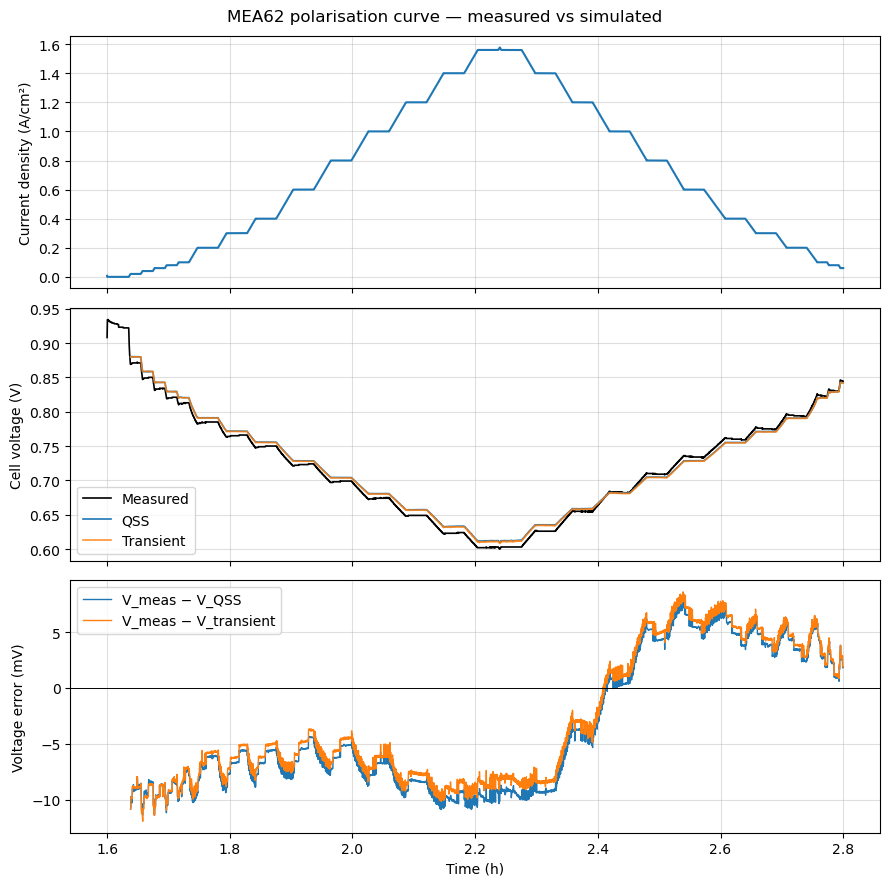

In [8]:
time_h = df['Time(h)'].to_numpy()
current_density_Acm2 = df['I_Pile(A)'].to_numpy() / CELL_AREA * 1e-4   # A/cm²
measured_V = df['U_Pile(V)'].to_numpy() / N_CELLS
window = (time_h >= T_START_H) & (time_h <= T_END_H)
t_w = time_h[window]

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(t_w, current_density_Acm2[window])
axes[0].set_ylabel('Current density (A/cm²)')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_w, measured_V[window], 'k', lw=1.2, label='Measured')
axes[1].plot(t_w, cell_voltage_qss[window], 'C0', lw=1.2, label='QSS')
axes[1].plot(t_w, cell_voltage_tr[window], 'C1', lw=1.2, alpha=0.85, label='Transient')
axes[1].set_ylabel('Cell voltage (V)')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

axes[2].plot(t_w, 1e3 * (measured_V[window] - cell_voltage_qss[window]),
             'C0', lw=1., label='V_meas − V_QSS')
axes[2].plot(t_w, 1e3 * (measured_V[window] - cell_voltage_tr[window]),
             'C1', lw=1., label='V_meas − V_transient')
axes[2].axhline(0, color='k', lw=0.7)
axes[2].set_ylabel('Voltage error (mV)')
axes[2].set_xlabel('Time (h)')
axes[2].legend()
axes[2].grid(True, alpha=0.4)

fig.suptitle('MEA62 polarisation curve — measured vs simulated')
fig.tight_layout()
plt.show()

### 7.2 MEA temperature during the polarisation curve

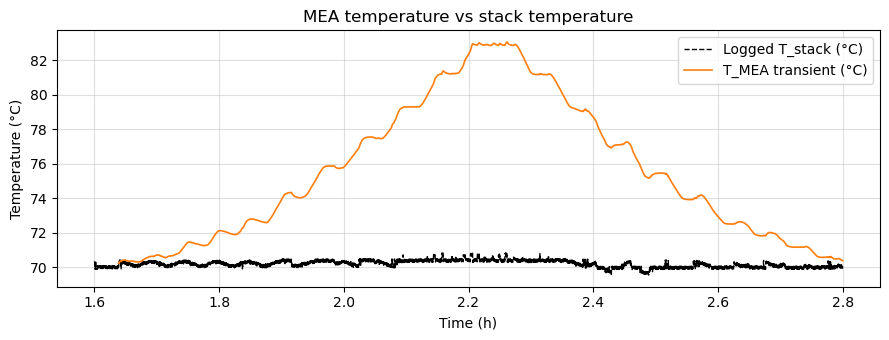

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t_w, df['T_pile(°C)'].to_numpy()[window], 'k--', lw=1., label='Logged T_stack (°C)')
ax.plot(t_w, T_mea_tr_all[window] - 273.15, 'C1', lw=1.2, label='T_MEA transient (°C)')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Temperature (°C)')
ax.set_title('MEA temperature vs stack temperature')
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

### 7.3 Membrane water-content profile snapshots

Profiles at regularly spaced times throughout the polarisation curve window,
coloured from early (blue) to late (red).
ξ = 0 is the anode interface; ξ = 1 is the cathode.

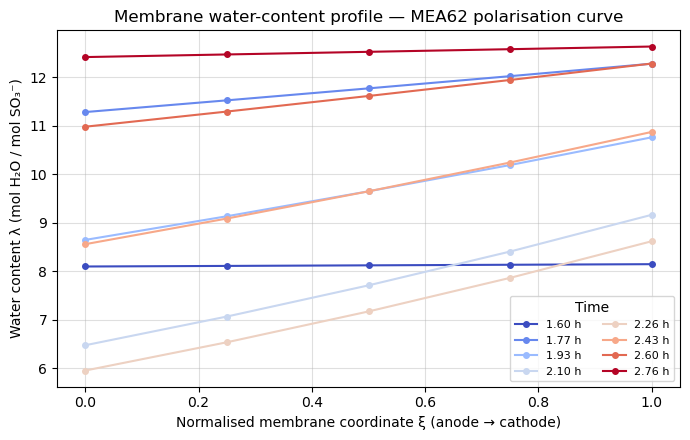

In [10]:
xi = np.linspace(0, 1, N_MESH)

# Sample 8 snapshots evenly through the polarisation-curve window
n_snaps   = 8
t_snaps_s = np.linspace(t_eval_s[0], t_eval_s[-1], n_snaps)
x_snaps   = sol.sol(t_snaps_s)
lmbd_snaps = x_snaps[1:, :]   # shape (N_MESH, n_snaps)

# Corresponding actual time labels in hours
t_snaps_h = T_START_H + t_snaps_s / 3600.

cmap   = cm.coolwarm
colors = cmap(np.linspace(0, 1, n_snaps))

fig, ax = plt.subplots(figsize=(7, 4.5))
for k in range(n_snaps):
    ax.plot(xi, lmbd_snaps[:, k], marker='o', markersize=4,
            color=colors[k], label=f'{t_snaps_h[k]:.2f} h')

ax.set_xlabel('Normalised membrane coordinate ξ (anode → cathode)')
ax.set_ylabel('Water content λ (mol H₂O / mol SO₃⁻)')
ax.set_title('Membrane water-content profile — MEA62 polarisation curve')
ax.legend(fontsize=8, ncol=2, title='Time')
ax.grid(True, alpha=0.4)
fig.tight_layout()
plt.show()

### 7.4 Time evolution of water content at each membrane node

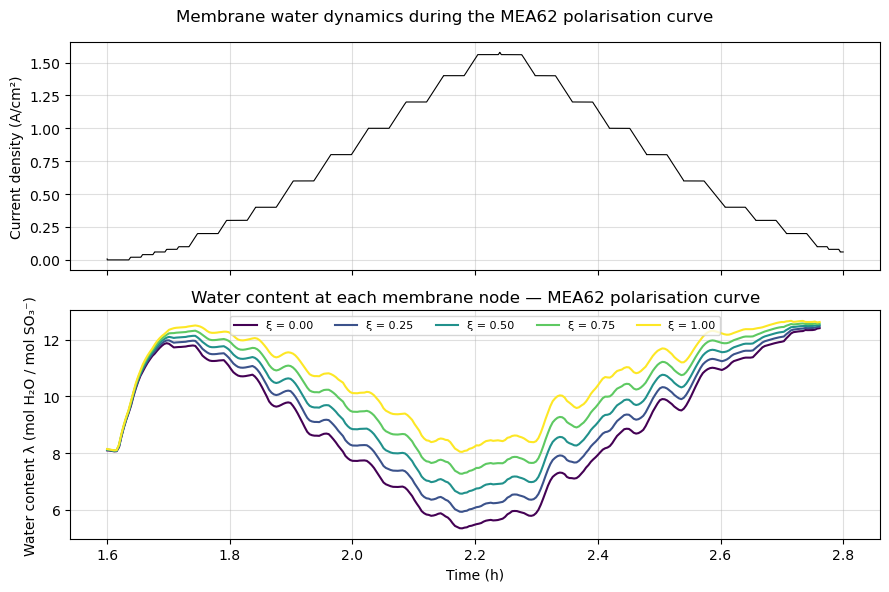

In [11]:
t_dense_s  = np.linspace(t_eval_s[0], t_eval_s[-1], 300)
x_dense    = sol.sol(t_dense_s)
lmbd_dense = x_dense[1:, :]   # (N_MESH, 300)
t_dense_h  = T_START_H + t_dense_s / 3600.

cmap_nodes  = cm.viridis
node_colors = cmap_nodes(np.linspace(0, 1, N_MESH))

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax = axes[0]
ax.plot(t_w, current_density_Acm2[window], color='k', lw=0.8)
ax.set_ylabel('Current density (A/cm²)')
ax.grid(True, alpha=0.4)

ax = axes[1]
for k in range(N_MESH):
    ax.plot(t_dense_h, lmbd_dense[k], color=node_colors[k],
            label=f'ξ = {xi[k]:.2f}')
ax.set_xlabel('Time (h)')
ax.set_ylabel('Water content λ (mol H₂O / mol SO₃⁻)')
ax.set_title('Water content at each membrane node — MEA62 polarisation curve')
ax.legend(fontsize=8, ncol=N_MESH)
ax.grid(True, alpha=0.4)

fig.suptitle('Membrane water dynamics during the MEA62 polarisation curve')
fig.tight_layout()
plt.show()